# 12 — Clustering (k‑means, Hierarchical, GMM)

**Prerequisite:** notebook 11. **Theory used:** §1.2, §6.2.

Clustering is **unsupervised** — there are no labels. You're asking the data
to organise itself into groups. This makes it powerful (find structure you
didn't know was there) and treacherous (no ground truth to check against, so
"is this a real cluster?" is genuinely hard). The three algorithms in this
notebook make **different assumptions** about cluster shape — and the failure
cases show what happens when you violate them.

## What you'll be able to do after this notebook

1. Explain k‑means, hierarchical, and Gaussian‑mixture clustering in plain words.
2. Choose the number of clusters with **elbow**, **silhouette**, and
 **BIC/AIC** — and know their limits.
3. Read a **dendrogram** for hierarchical clustering.
4. Match the algorithm to the cluster **shape** you expect (spherical / nested /
 arbitrary).
5. Recognise the two big failure modes: **k‑means on non‑spherical clusters**,
 and **finding clusters in data that has none**.

## The process

```mermaid
flowchart TD
 SC["Scale the data<br/> every distance-based method needs this — §1.2"] --> EXP
 EXP["Explore: scatter the data, eyeball cluster shapes"] --> PICK
 PICK{{"Expected shape?"}}
 PICK -->|spherical, similar size| KM["k-means"]
 PICK -->|nested / unknown hierarchy| HC["hierarchical"]
 PICK -->|elliptical / overlapping| GMM["GMM"]
 KM --> K["choose k: elbow + silhouette"]
 HC --> D["read dendrogram, cut at a height"]
 GMM --> B["choose k: BIC / AIC"]
```

## 1. The three algorithms, in plain language

| Algorithm | What it assumes | How it groups | Output |
|---|---|---|---|
| **k‑means** | clusters are **spherical** (≈ round) and similar in size | iteratively place k centroids, assign each point to the nearest | one hard label per point |
| **Hierarchical** | clusters nest into a tree of clusters | merge (or split) closest pairs one at a time | a **dendrogram**; cut it at any height for a chosen k |
| **GMM** (Gaussian mixture) | each cluster is a **Gaussian blob** (can be elliptical) | fit k Gaussians; each point has a *probability* of belonging to each | soft (probabilistic) membership |

> The key insight of this whole notebook: **no clustering algorithm is
> shape‑agnostic**. k‑means will *force* spherical clusters even if the real
> ones are rings; GMM will *force* ellipses. Pick the algorithm whose assumption
> matches your data, or you'll get confidently wrong groups (the failure case in §6).

## 2. Worked example A — k‑means on a clean dataset (iris)

Even though iris has labels, we'll **ignore them** — pretend it's unsupervised —
then check whether k‑means recovers the species. That recovery is the
sanity check.

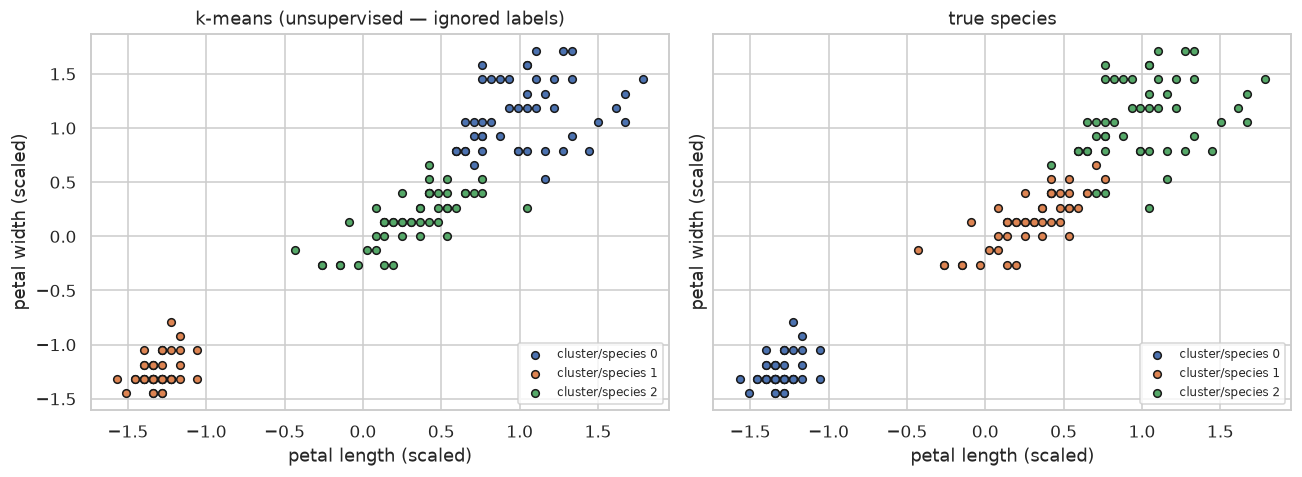

Adjusted Rand Index vs true labels: 0.886


In [1]:
from setup import *
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score

iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values # 2 features so we can plot
y_true = iris.target.values

# Always scale before clustering.
Xs = StandardScaler().fit_transform(X)

km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(Xs)
labels = km.labels_

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)
for i, (lab, title) in enumerate([(labels, "k-means (unsupervised — ignored labels)"),
                                  (y_true, "true species")]):
    for c in range(3):
        ax[i].scatter(Xs[lab==c, 0], Xs[lab==c, 1], s=25, edgecolor="k",
                      label=f"cluster/species {c}")
    ax[i].set_title(title); ax[i].legend(fontsize=8, loc="lower right")
    ax[i].set_xlabel("petal length (scaled)"); ax[i].set_ylabel("petal width (scaled)")
plt.tight_layout(); plt.show()

# How well did k-means recover the species? (Adjusted Rand Index: 1=perfect)
print(f"Adjusted Rand Index vs true labels: {adjusted_rand_score(y_true, labels):.3f}")

k‑means recovers the species almost perfectly on iris — because iris clusters
**are** roughly spherical and similar‑sized, which is exactly what k‑means
assumes. (Note setosa is cleanly separated; the versicolor/virginica overlap
produces a couple of misassignments.)

> **ARI (Adjusted Rand Index)** is the honest "did clustering recover the real
> groups?" score when you *do* have labels for checking: 1 = perfect, 0 =
> random. During real unsupervised work you don't have it — use the silhouette
> score instead.

## 3. Choosing k — elbow + silhouette

Without labels, how do you pick the number of clusters? Two complementary
diagnostics:

- **Elbow (inertia):** plot k‑means' within‑cluster sum of squares vs k. The
 "elbow" is where adding a cluster stops helping much.
- **Silhouette** (per point, averaged): how similar a point is to its own cluster
 vs the *next nearest* cluster. Range [−1, 1]; higher = better separated.

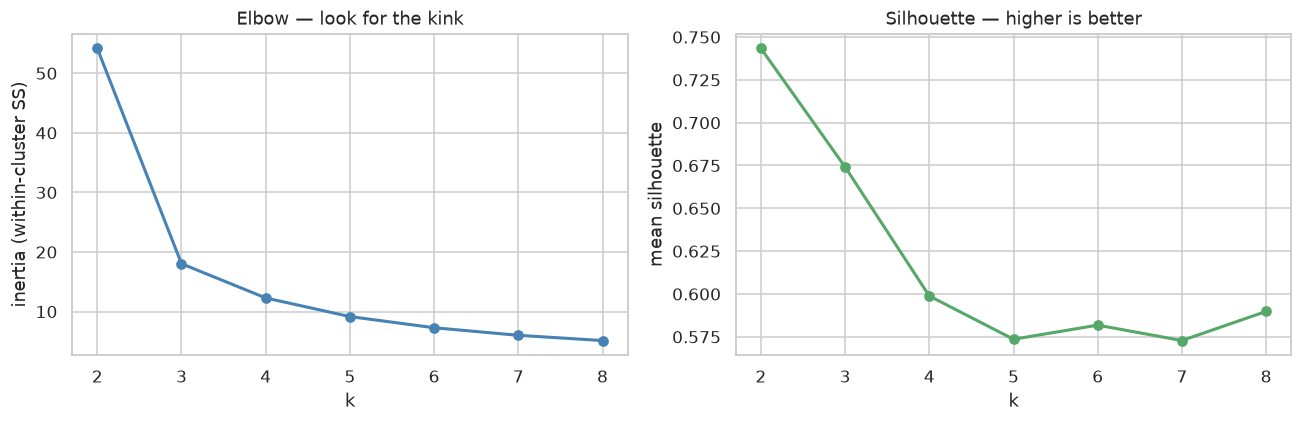

best silhouette at k=2


In [2]:
ks = range(2, 9)
inertias, sils = [], []
for k in ks:
 km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xs)
 inertias.append(km.inertia_)
 sils.append(silhouette_score(Xs, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ks, inertias, "o-", color="steelblue", lw=2)
ax[0].set_xlabel("k"); ax[0].set_ylabel("inertia (within-cluster SS)")
ax[0].set_title("Elbow — look for the kink")
ax[1].plot(ks, sils, "o-", color="#55a868", lw=2)
ax[1].set_xlabel("k"); ax[1].set_ylabel("mean silhouette")
ax[1].set_title("Silhouette — higher is better")
plt.tight_layout(); plt.show()
print(f"best silhouette at k={list(ks)[np.argmax(sils)]}")

**Reading the curves:** the elbow often *suggests* k=2 or 3 (the bend), while
the silhouette peaks where clusters are best separated. When they disagree —
common — prefer the silhouette, but treat both as *hints* and look at the
scatterplot. There is no "true k" without domain knowledge (see §7).

## 4. Hierarchical clustering and the dendrogram

Hierarchical clustering builds a **tree of merges**. You don't have to pick k
up front — you cut the tree at a chosen height to get that many clusters. The
**dendrogram** visualises the whole structure at once.

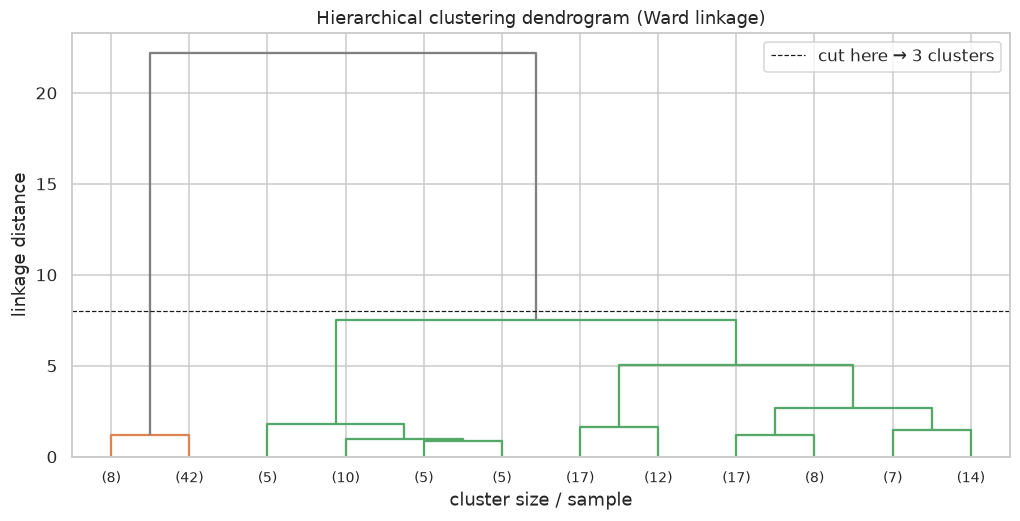

hierarchical (3) ARI vs true: 0.636
k-means (3) ARI vs true: 0.886


In [3]:
# Ward linkage minimises within-cluster variance (closest in spirit to k-means).
Z = linkage(Xs, method="ward")

plt.figure(figsize=(11, 5))
dendrogram(Z, truncate_mode="lastp", p=12, show_leaf_counts=True, leaf_font_size=9,
 color_threshold=8, above_threshold_color="grey")
plt.axhline(8, color="k", ls="--", lw=0.8, label="cut here → 3 clusters")
plt.title("Hierarchical clustering dendrogram (Ward linkage)")
plt.xlabel("cluster size / sample"); plt.ylabel("linkage distance")
plt.legend(); plt.show()

# Cut to get 3 clusters and compare to k-means / truth.
hier_labels = fcluster(Z, t=3, criterion="maxclust")
print(f"hierarchical (3) ARI vs true: {adjusted_rand_score(y_true, hier_labels):.3f}")
print(f"k-means (3) ARI vs true: {adjusted_rand_score(y_true, KMeans(3, n_init=10, random_state=42).fit_predict(Xs)):.3f}")

**Reading the dendrogram:** the height at which two clusters merge = how
dissimilar they are. Long vertical lines = big jumps = natural cluster
boundaries. Cut at a horizontal line that crosses only tall verticals for a
clean partition. The dendrogram is hierarchical clustering's superpower — you
see *all* possible k at once, and the merge structure often matches domain
hierarchy (sub‑species → species → genus).

## 5. Gaussian Mixture Models — soft, elliptical clusters

GMM fits $k$ Gaussian distributions to the data via the EM algorithm. Unlike
k‑means it returns **probabilities** (soft membership) and can model
**elliptical** clusters of different sizes/orientations. Choose $k$ with
**BIC** (lower is better) — it balances fit against complexity.

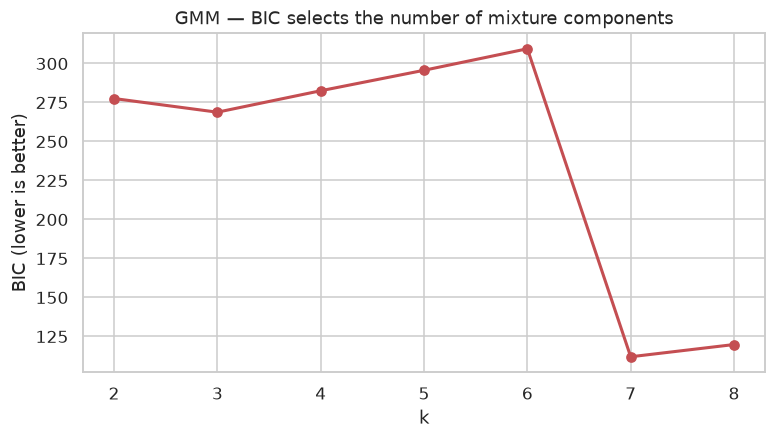

GMM best k = 7, ARI vs true = 0.619


In [4]:
bics = []
for k in ks:
 g = GaussianMixture(n_components=k, random_state=42, n_init=3).fit(Xs)
 bics.append(g.bic(Xs))

plt.plot(ks, bics, "o-", color="#c44e52", lw=2)
plt.xlabel("k"); plt.ylabel("BIC (lower is better)")
plt.title("GMM — BIC selects the number of mixture components")
plt.show()

gmm = GaussianMixture(n_components=list(ks)[np.argmin(bics)], random_state=42, n_init=3).fit(Xs)
gmm_labels = gmm.predict(Xs)
print(f"GMM best k = {list(ks)[np.argmin(bics)]}, ARI vs true = {adjusted_rand_score(y_true, gmm_labels):.3f}")

On iris all three methods roughly agree (k=3, good recovery) — because iris
matches everyone's assumptions. The interesting story is when the methods
*disagree*, which happens when the data violates an assumption. That's the
failure case next.

## 6. Failure case 1 — k‑means on non‑spherical clusters

k‑means **assumes spherical, similar‑sized clusters** because it minimises
Euclidean distance to centroids. The classic counterexample: two concentric
rings (or two moons). k‑means will cut them into pie slices — confidently
wrong. GMM won't help either (rings aren't Gaussian). The right tool is
**DBSCAN** (density‑based) or **spectral clustering**.

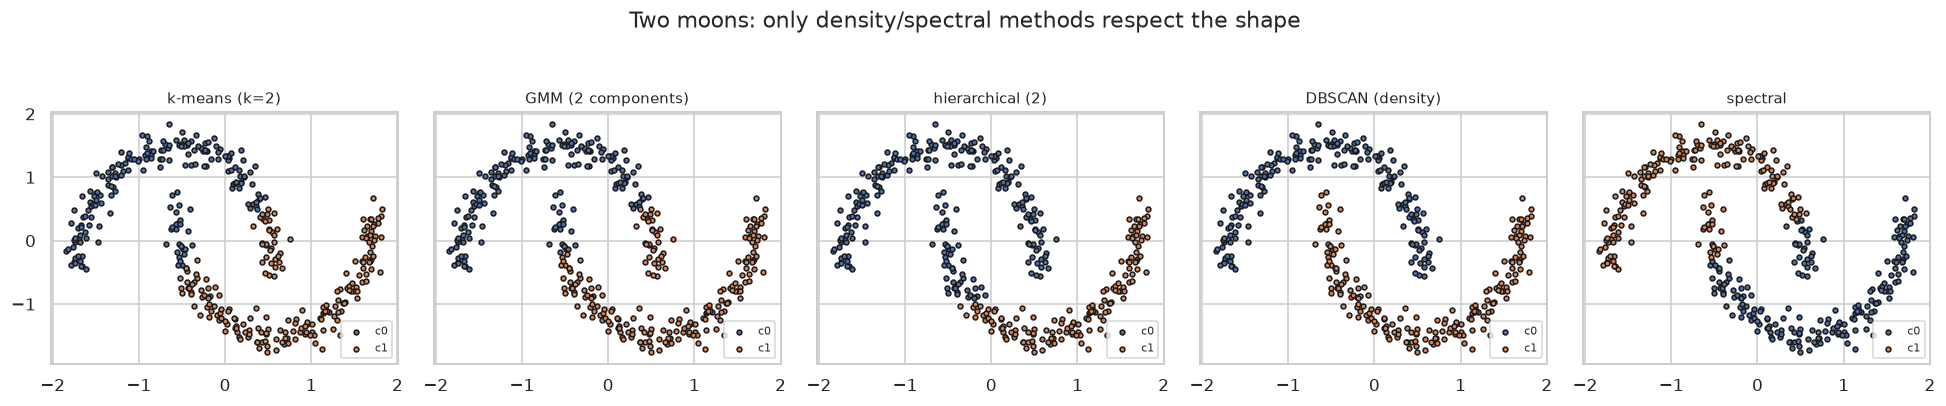

In [5]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN, SpectralClustering

Xm, _ = make_moons(n_samples=400, noise=0.07, random_state=0)
Xms = StandardScaler().fit_transform(Xm)

algorithms = {
 "k-means (k=2)": KMeans(n_clusters=2, n_init=10, random_state=42),
 "GMM (2 components)": GaussianMixture(n_components=2, random_state=42, n_init=3),
 "hierarchical (2)": AgglomerativeClustering(n_clusters=2, linkage="average"),
 "DBSCAN (density)": DBSCAN(eps=0.3, min_samples=5),
 "spectral": SpectralClustering(n_clusters=2, random_state=42, n_jobs=-1),
}
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), sharex=True, sharey=True)
for ax, (name, algo) in zip(axes, algorithms.items()):
    if name.startswith("GMM"):
        lab = algo.fit(Xms).predict(Xms)
    else:
        lab = algo.fit_predict(Xms)
    # DBSCAN labels -1 as noise
    for c in np.unique(lab):
        mask = lab == c
        ax.scatter(Xms[mask, 0], Xms[mask, 1], s=10, edgecolor="k",
                   label="noise" if c == -1 else f"c{c}")
    ax.set_title(name, fontsize=10); ax.legend(fontsize=7, loc="lower right")
plt.suptitle("Two moons: only density/spectral methods respect the shape", y=1.05)
plt.tight_layout(); plt.show()

**What just happened (the headline clustering failure):** k‑means, GMM, and
hierarchical all slice the moons into pieces — they cannot represent "two
interlocking crescents" because each assumes compact blobs. Only **DBSCAN**
(follows dense regions) and **spectral** (uses graph connectivity) recover the
true two‑moon structure.

> **The lesson:** the algorithm is not interchangeable. The biggest clustering
> question is *"what shape are my clusters?"*, and the answer dictates the
> method. Reach for DBSCAN when clusters are arbitrary/dense, GMM when they're
> overlapping ellipses, k‑means when they're clean round blobs.

## 7. Failure case 2 — finding clusters in data that has none

Every clustering algorithm above **will return clusters no matter what you feed
it** — even pure noise. The silhouette score can look "okay" on random data.
This is the deepest clustering trap: **there is no ground truth to reject the
result**, so spurious clusters ship to the business.

silhouette on pure noise (k=4): 0.413 <- looks meaningful!


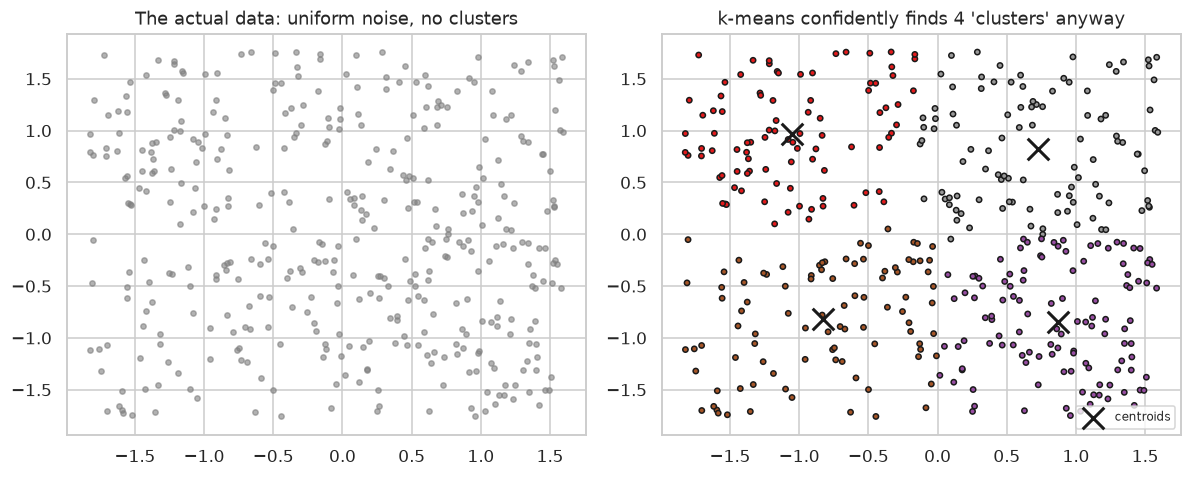

In [6]:
# Uniform random noise in 2D. There are NO real clusters.
rng = np.random.default_rng(0)
noise = rng.uniform(-3, 3, (400, 2))
noise_s = StandardScaler().fit_transform(noise)

# k=4 k-means finds 4 "clusters" anyway — and the silhouette looks decent.
km_noise = KMeans(n_clusters=4, n_init=10, random_state=42).fit(noise_s)
print(f"silhouette on pure noise (k=4): {silhouette_score(noise_s, km_noise.labels_):.3f} <- looks meaningful!")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].scatter(noise_s[:, 0], noise_s[:, 1], s=12, color="grey", alpha=0.6)
ax[0].set_title("The actual data: uniform noise, no clusters")
ax[1].scatter(noise_s[:, 0], noise_s[:, 1], c=km_noise.labels_, cmap="Set1", s=12, edgecolor="k")
ax[1].scatter(*km_noise.cluster_centers_.T, marker="x", s=200, color="k", lw=2, label="centroids")
ax[1].set_title("k-means confidently finds 4 'clusters' anyway"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**The diagnostic that catches this:** compare the silhouette to a **null
reference** — cluster *uniformly random* data of the same dimension and see what
silhouette you'd get by chance. If the real silhouette isn't clearly higher, you
have no evidence of structure. (scikit‑learn doesn't ship this directly; the
technique is a *graphical null test* — sketch one silhouette per k for both real
and random data side by side.)

> **The rule:** clustering results need *more* scepticism than supervised
> results, not less. Always:
> 1. **Plot the data first** — eyeball for actual structure before trusting any
> algorithm.
> 2. **Compare to a null** — would random data score this well?
> 3. **Check stability** — bootstrap the data and see if the same clusters
> reappear. If they shuffle, you've found noise.
> 4. **Get domain validation** — does a human expert recognise the segments?

## 8. Worked example B — clustering the CEO dataset

The CEO data is tiny (60 rows) and mostly categorical, so clustering is a
stretch — but it's instructive for the *preprocessing* (you can't k‑means raw
categoricals). We one‑hot + scale, then k‑means on the security‑investment
features.

In [7]:
ceo = pd.read_csv("data/ceo_data.csv")
# Pick the numeric-ish security features + a one-hot of Sector
feat = ceo[["Security_Invest", "Security_Breach_Att", "Succ_Sec_Breaches", "LOT_in_Business"]].copy()
ohe = pd.get_dummies(ceo["Sector"], prefix="Sector", dtype=float)
Xc = pd.concat([feat, ohe], axis=1)
Xcs = StandardScaler().fit_transform(Xc)

# Silhouette across k
ceoks = range(2, 7)
ceil_sils = [silhouette_score(Xcs, KMeans(k, n_init=10, random_state=42).fit_predict(Xcs)) for k in ceoks]
best_k = list(ceoks)[np.argmax(ceil_sils)]
print(f"best silhouette at k={best_k} (sil={max(ceil_sils):.3f})")
print("(with only 60 rows, take this with a large pinch of salt — see §7)")

best silhouette at k=5 (sil=0.532)
(with only 60 rows, take this with a large pinch of salt — see §7)


On 60 rows the silhouette is weak and unstable — clustering needs density, and
tiny datasets don't have it. (Compare with the supervised models in earlier
notebooks, which also struggled on CEO for the same reason: not enough data.)
That's an honest result, and it's the right answer to report — not a forced
"3 segments" story.

## Common pitfalls & how to avoid shooting yourself in the foot

1. **Unscaled features (§2–8).** Every method here is distance‑based. Scale
 first, always.
2. **Wrong‑shape algorithm (§6).** k‑means on rings/moons = pie slices. Match
 the algorithm to the cluster shape (eyeball a scatterplot first).
3. **Treating k from elbow/silhouette as ground truth (§3).** They're hints,
 often disagreeing. Domain knowledge decides; the metrics only suggest.
4. **Clustering noise (§7).** Algorithms always return labels. Always compare
 to a null and check stability before believing the segments.
5. **Forgetting `n_init`** for k‑means. Default `n_init=10` (or `"auto"`) runs
 the algorithm from multiple starts and keeps the best — crucial because
 k‑means gets stuck in local minima.
6. **One‑hotting high‑cardinality categoricals** before k‑means. The many 0/1
 dimensions drown the numeric signal. Reduce (PCA / MCA) or pick a method
 suited to mixed data (Gower distance + PAM).
7. **Interpreting clusters as causal segments (§3).** "These customers form
 a cluster, so they behave the same way" is a correlation, not a causal claim.

## Exercises

1. **Shape matching.** Generate three datasets — blobs (`make_blobs`), moons
 (`make_moons`), concentric circles (`make_circles`). On each, report ARI for
 k‑means, GMM, hierarchical, and DBSCAN. Which wins on each shape?
2. **k yourself.** On the **wine** dataset (ignore labels), plot silhouette vs k
 for k‑means (k=2..8). Does the best k match the true 3 cultivars? (You can
 check with ARI.)
3. **DBSCAN's epsilon.** On the moons data, sweep `eps` from 0.05 to 0.6. At
 what `eps` does DBSCAN stop finding the two moons and start labelling
 everything as one cluster / all noise? Why is `eps` the hard part of DBSCAN?
4. **Clustering noise, null test.** Generate uniform noise, fit k‑means k=2..6,
 and plot the silhoutes. Now repeat on real iris. Is the iris silhouette
 clearly above the noise floor? How would you make this into a proper
 hypothesis test?
5. **Stability check.** Bootstrap the CEO clustering: resample 60 rows with
 replacement 10 times, refit k‑means k=3, and compare the label assignments
 (ARI between runs). High stability = real structure; low = noise.

<details><summary>Answers (click to expand)</summary>

```python
# 1: blobs -> k-means/GMM win; moons -> DBSCAN/spectral win; circles -> DBSCAN/
# spectral win. That's the whole shape-matching lesson.

# 2
from sklearn.datasets import load_wine
w = load_wine(as_frame=True)
Xw = StandardScaler().fit_transform(w.data)
for k in range(2, 9):
 lab = KMeans(k, n_init=10, random_state=42).fit_predict(Xw)
 print(k, round(silhouette_score(Xw, lab), 3),
 "ARI=", round(adjusted_rand_score(w.target, lab), 3))

# 3: eps too small -> most points labelled -1 (noise); eps too big -> one giant
# cluster. The right eps sits where stable dense regions emerge. Use a
# k-distance plot (sort distances to k-th neighbour) to pick the knee.

# 4: noise silhouettes are low but non-zero (~0.3-0.4 on 2D uniform). iris is
# clearly higher (~0.5+). A proper test: compute the distribution of
# silhouette under the null (many noise samples) and check where the real
# value falls -> a permutation / null-distribution p-value.

# 5: On 60 rows ARI between bootstrap runs is usually low (~0.3-0.6) -> the
# clusters are unstable -> they're mostly noise. That's the honest signal.
```
</details>

## References

- **Theory & Statistics Reference** (`00_Theory_Reference.ipynb`) — §1.2
 (variance/distance & scaling), §3 (clusters ≠ causal segments), §6.2
 (algorithm assumptions as bias).
- Textbook: Boehmke & Greenwell, *HOML*, Ch. 20–22 —
 <https://bradleyboehmke.github.io/HOML/kmeans.html>.
- scikit‑learn — *Clustering* user guide (with the famous clustering‑on‑shape
 comparison figure):
 <https://scikit-learn.org/stable/modules/clustering.html>.
- Ester et al. (1996), *DBSCAN*; Dempster et al. (1977), *EM for GMMs*.
- Guyon et al. (2009), *Stability and clustering* — on bootstrap stability as a
 cluster‑validity signal.